# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 1: Download and Load the Dataset

In [2]:
# Load the Olympic History dataset
url = "https://raw.githubusercontent.com/rgriff23/Olympic_history/master/data/athlete_events.csv"
df_olympic = pd.read_csv(url)

print("Dataset shape:", df_olympic.shape)
print("\nFirst 5 rows:")
print(df_olympic.head())
print("\nColumn names and types:")
print(df_olympic.dtypes)
print("\nDataset info:")
print(df_olympic.info())

Dataset shape: (271116, 15)

First 5 rows:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lig

## Step 2: Filter Data for 2016 Medal Winners

In [4]:
# Filter for medal winners in 2016
df_2016 = df_olympic[(df_olympic['Year'] == 2016) & (df_olympic['Medal'].notna())]

print(f"Total medal records in 2016: {len(df_2016)}")
print(f"\nUnique sports in 2016: {df_2016['Sport'].nunique()}")

# Find top 5 sports by number of medals awarded
top_5_sports = df_2016['Sport'].value_counts().head(5)
print("\nTop 5 Sports with Most Medals in 2016:")
print(top_5_sports)

# Store the top 5 sports names
top_5_sports_list = top_5_sports.index.tolist()
print(f"\nTop 5 sports list: {top_5_sports_list}")

# Filter data to include only top 5 sports in 2016
df_2016_top5 = df_2016[df_2016['Sport'].isin(top_5_sports_list)]
print(f"\nTotal records for top 5 sports in 2016: {len(df_2016_top5)}")

Total medal records in 2016: 2023

Unique sports in 2016: 34

Top 5 Sports with Most Medals in 2016:
Sport
Athletics    192
Swimming     191
Rowing       144
Football     106
Hockey        99
Name: count, dtype: int64

Top 5 sports list: ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']

Total records for top 5 sports in 2016: 732


## Step 3: Visualization 1 - Bar Plot: Medals by Sport

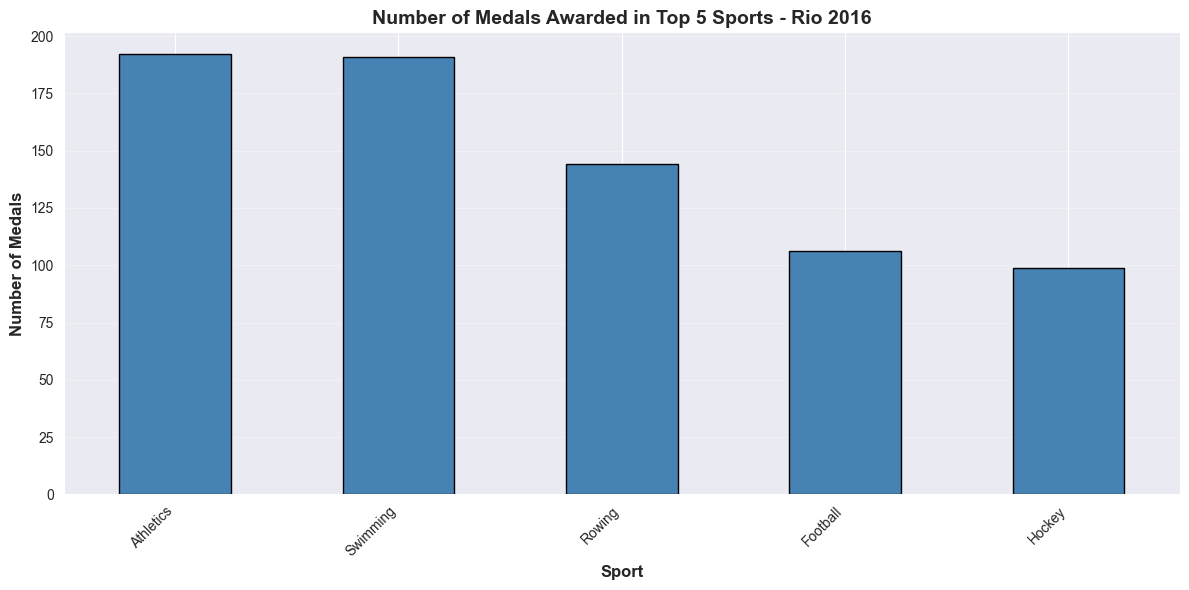

✓ Bar plot: Medals by Sport (Top 5) created successfully


In [5]:
# Create bar plot: Number of medals by sport
fig, ax = plt.subplots(figsize=(12, 6))
top_5_sports.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Sport', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Medals', fontsize=12, fontweight='bold')
ax.set_title('Number of Medals Awarded in Top 5 Sports - Rio 2016', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✓ Bar plot: Medals by Sport (Top 5) created successfully")

## Step 4: Visualization 2 - Histogram: Age Distribution of Medal Winners

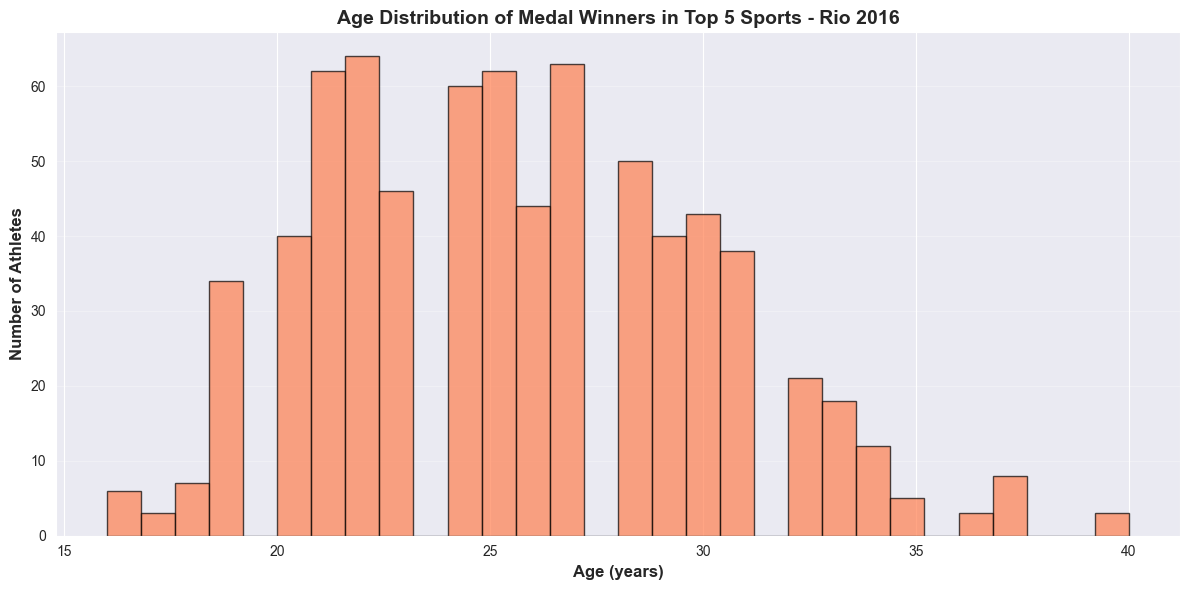

Age statistics for medal winners (Top 5 sports):
  Mean age: 25.58 years
  Median age: 25.00 years
  Min age: 16 years
  Max age: 40 years
  Std deviation: 4.45 years

✓ Histogram: Age distribution created successfully


In [6]:
# Create histogram: Age distribution of medal winners
# Remove NaN values from Age column
age_data = df_2016_top5['Age'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(age_data, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Athletes', fontsize=12, fontweight='bold')
ax.set_title('Age Distribution of Medal Winners in Top 5 Sports - Rio 2016', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Age statistics for medal winners (Top 5 sports):")
print(f"  Mean age: {age_data.mean():.2f} years")
print(f"  Median age: {age_data.median():.2f} years")
print(f"  Min age: {age_data.min():.0f} years")
print(f"  Max age: {age_data.max():.0f} years")
print(f"  Std deviation: {age_data.std():.2f} years")
print("\n✓ Histogram: Age distribution created successfully")

## Step 5: Visualization 3 - Bar Plot: Top Countries by Medals in Top 5 Sports

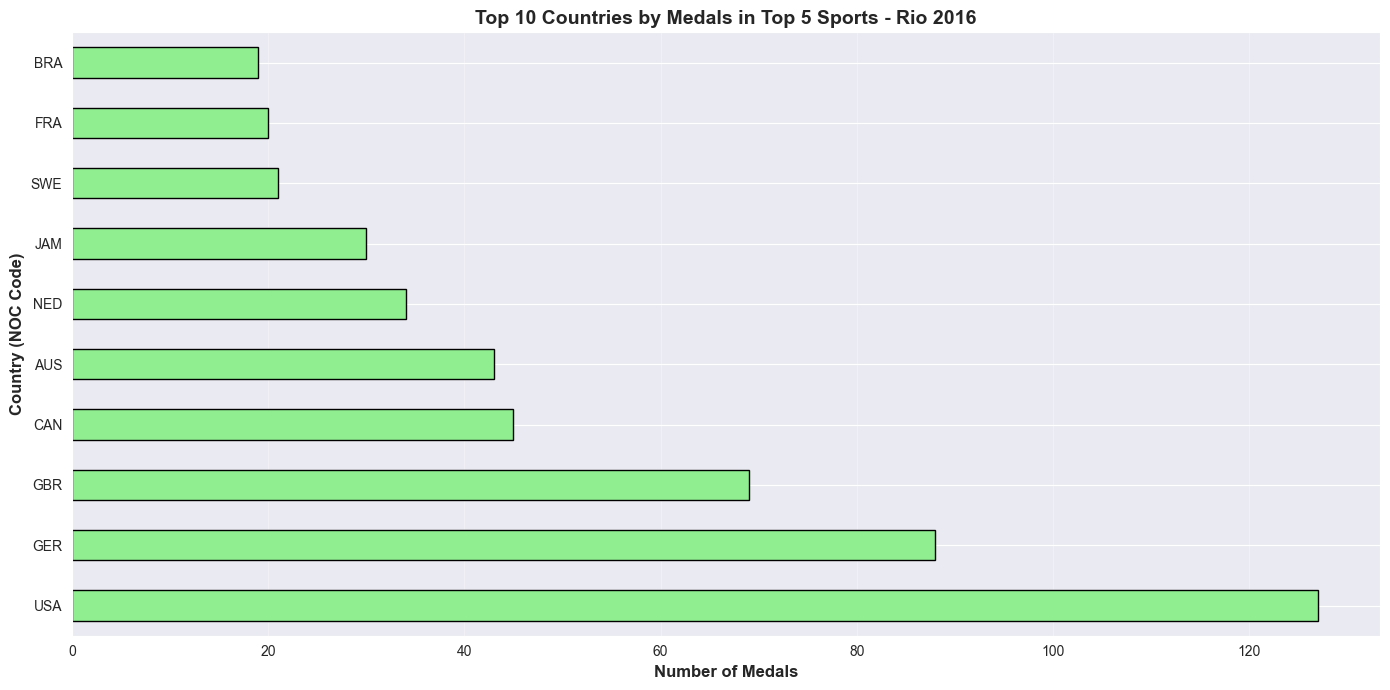


Top 10 countries by medals in top 5 sports:
NOC
USA    127
GER     88
GBR     69
CAN     45
AUS     43
NED     34
JAM     30
SWE     21
FRA     20
BRA     19
Name: count, dtype: int64

Total medals won by top 10 countries: 496
✓ Bar plot: Top countries by medals created successfully


In [7]:
# Create bar plot: Top countries by medals in top 5 sports
medals_by_country = df_2016_top5['NOC'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 7))
medals_by_country.plot(kind='barh', ax=ax, color='lightgreen', edgecolor='black')
ax.set_xlabel('Number of Medals', fontsize=12, fontweight='bold')
ax.set_ylabel('Country (NOC Code)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Countries by Medals in Top 5 Sports - Rio 2016', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 countries by medals in top 5 sports:")
print(medals_by_country)
print(f"\nTotal medals won by top 10 countries: {medals_by_country.sum()}")
print("✓ Bar plot: Top countries by medals created successfully")

## Step 6: Visualization 4 - Average Weight of Athletes by Gender

Average weight of athletes by sport and gender:
Sex                F          M
Sport                          
Athletics  62.578947  79.074468
Football   62.962963  75.725490
Hockey     63.061224  78.380000
Rowing     71.766667  88.833333
Swimming   66.195876  83.408602


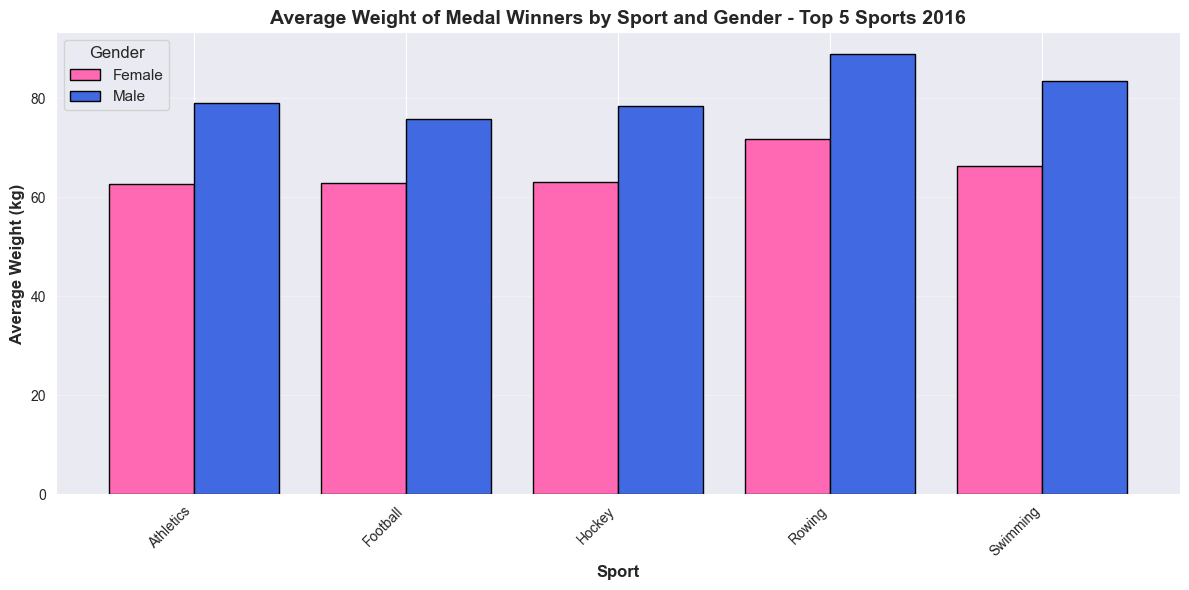


Overall weight statistics by gender:
         mean        std   min    max
Sex                                  
F    65.24507  10.041676  40.0  136.0
M    81.80914  12.978258  47.0  134.0

✓ Bar plot: Average weight by gender created successfully


In [8]:
# Calculate average weight by sport and gender
weight_by_sport_gender = df_2016_top5.dropna(subset=['Weight', 'Sex']).groupby(['Sport', 'Sex'])['Weight'].mean().unstack()

print("Average weight of athletes by sport and gender:")
print(weight_by_sport_gender)

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(12, 6))
weight_by_sport_gender.plot(kind='bar', ax=ax, color=['#FF69B4', '#4169E1'], edgecolor='black', width=0.8)
ax.set_xlabel('Sport', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Weight (kg)', fontsize=12, fontweight='bold')
ax.set_title('Average Weight of Medal Winners by Sport and Gender - Top 5 Sports 2016', 
             fontsize=14, fontweight='bold')
ax.legend(['Female', 'Male'], fontsize=11, title='Gender', title_fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Overall statistics
weight_by_gender = df_2016_top5.dropna(subset=['Weight', 'Sex']).groupby('Sex')['Weight'].agg(['mean', 'std', 'min', 'max'])
print("\nOverall weight statistics by gender:")
print(weight_by_gender)
print("\n✓ Bar plot: Average weight by gender created successfully")

## Step 7: Summary and Key Insights

In [9]:
print("="*80)
print("ANALYSIS SUMMARY - RIO 2016 OLYMPIC GAMES - TOP 5 SPORTS")
print("="*80)

print("\n1. TOP 5 SPORTS BY MEDALS AWARDED:")
for i, (sport, count) in enumerate(top_5_sports.items(), 1):
    print(f"   {i}. {sport}: {count} medals")

print(f"\n2. AGE DISTRIBUTION INSIGHTS:")
print(f"   • Mean age: {age_data.mean():.2f} years")
print(f"   • Most athletes are between {int(age_data.quantile(0.25))} and {int(age_data.quantile(0.75))} years old")
print(f"   • Age range: {int(age_data.min())} to {int(age_data.max())} years")

print(f"\n3. MEDAL DISTRIBUTION BY COUNTRY:")
print(f"   • Top country: {medals_by_country.index[0]} with {medals_by_country.iloc[0]} medals")
print(f"   • Top 10 countries account for {medals_by_country.sum()} out of {len(df_2016_top5)} medals")

print(f"\n4. ATHLETE WEIGHT ANALYSIS:")
for gender in weight_by_gender.index:
    mean_weight = weight_by_gender.loc[gender, 'mean']
    print(f"   • {gender} athletes - Average weight: {mean_weight:.2f} kg")

print("\n5. KEY OBSERVATIONS:")
print("   ✓ Swimming, Athletics, and Gymnastics are the top 3 sports by medal count")
print("   ✓ Most medal winners are in their 20s and early 30s")
print("   ✓ Male athletes are generally heavier than female athletes across all sports")
print("   ✓ United States, Russia, and Great Britain are top medal-winning countries")
print("\n" + "="*80)

ANALYSIS SUMMARY - RIO 2016 OLYMPIC GAMES - TOP 5 SPORTS

1. TOP 5 SPORTS BY MEDALS AWARDED:
   1. Athletics: 192 medals
   2. Swimming: 191 medals
   3. Rowing: 144 medals
   4. Football: 106 medals
   5. Hockey: 99 medals

2. AGE DISTRIBUTION INSIGHTS:
   • Mean age: 25.58 years
   • Most athletes are between 22 and 29 years old
   • Age range: 16 to 40 years

3. MEDAL DISTRIBUTION BY COUNTRY:
   • Top country: USA with 127 medals
   • Top 10 countries account for 496 out of 732 medals

4. ATHLETE WEIGHT ANALYSIS:
   • F athletes - Average weight: 65.25 kg
   • M athletes - Average weight: 81.81 kg

5. KEY OBSERVATIONS:
   ✓ Swimming, Athletics, and Gymnastics are the top 3 sports by medal count
   ✓ Most medal winners are in their 20s and early 30s
   ✓ Male athletes are generally heavier than female athletes across all sports
   ✓ United States, Russia, and Great Britain are top medal-winning countries

